In [2]:
import os
from tqdm import tqdm
from collections import defaultdict

import numpy as np
import pandas as pd
import random
from collections import deque

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import warnings
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torch.optim import Adam
import numpy as np
import dgl
import dgl.data
from dgl.data import load_data
import networkx as nx
import matplotlib.pyplot as plt


In [3]:
#lab1/data/movie_lens/ml-latest-small/movies.csv

In [4]:
data_path = '/home/x1113496/lab1/data/movie_lens/ml-latest-small/'
#lab1/data/movie_lens/ml-latest-small/movies.csv

In [5]:
movies =  pd.read_csv(os.path.join(data_path, 'movies.csv'))

In [6]:
movies

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy
...,...,...,...
9737,193581,Black Butler: Book of the Atlantic (2017),Action|Animation|Comedy|Fantasy
9738,193583,No Game No Life: Zero (2017),Animation|Comedy|Fantasy
9739,193585,Flint (2017),Drama
9740,193587,Bungo Stray Dogs: Dead Apple (2018),Action|Animation


In [7]:
ratings = pd.read_csv(os.path.join(data_path, 'ratings.csv'))
ratings

,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931
...,...,...,...,...
100831,610,166534,4.0,1493848402
100832,610,168248,5.0,1493850091
100833,610,168250,5.0,1494273047
100834,610,168252,5.0,1493846352


In [53]:
#

In [8]:
rdata = pd.read_csv(os.path.join(data_path, 'ratings.csv'))

In [9]:
rdata['userId'] = 'u' + rdata['userId'].astype(str)
rdata['movieId'] = 'i' + rdata['movieId'].astype(str)

In [10]:
rdata

,userId,movieId,rating,timestamp
0,u1,i1,4.0,964982703
1,u1,i3,4.0,964981247
2,u1,i6,4.0,964982224
3,u1,i47,5.0,964983815
4,u1,i50,5.0,964982931
...,...,...,...,...
100831,u610,i166534,4.0,1493848402
100832,u610,i168248,5.0,1493850091
100833,u610,i168250,5.0,1494273047
100834,u610,i168252,5.0,1493846352


In [11]:
movieG = nx.Graph()
movieG.add_nodes_from(rdata.userId, bipartite=0)
movieG.add_nodes_from(rdata.movieId, bipartite=1)



In [12]:
movieG

In [64]:
movieG.is_directed(), movieG.is_multigraph(), is_bipartite(movieG)

(False, False, True)

In [65]:
color_map = []
for node in movieG.nodes:
    if str(node).startswith('u'):
        color_map.append('yello')
    else:
        color_map.append('green')

In [66]:
pos = nx.spring_layout(movieG)
plt.figure(3,figsize=(12,12))
nx.draw(movieG,pos,node_color=color_map)
plt.show()


KeyboardInterrupt: 

In [67]:
print(nx.info(movieG))

AttributeError: module 'networkx' has no attribute 'info'

In [68]:
movieG.number_of_nodes()

10334

In [62]:
from networkx import *

In [59]:
from networkx.algorithms import bipartite

In [16]:
ratings = pd.read_csv(os.path.join(data_path, 'ratings.csv'))
ratings = ratings.sort_values(['userId', 'timestamp']).reset_index(drop = True)
ratings['userId'] = ratings['userId'].astype(str)
ratings['movieId'] = ratings['movieId'].astype(str)

movies = pd.read_csv(os.path.join(data_path, 'movies.csv'))
movies['movieId'] = movies['movieId'].astype(str)

In [17]:
ratings

,userId,movieId,rating,timestamp
0,1,804,4.0,964980499
1,1,1210,5.0,964980499
2,1,2018,5.0,964980523
3,1,2628,4.0,964980523
4,1,2826,4.0,964980523
...,...,...,...,...
100831,610,101739,3.5,1495959269
100832,610,70,4.0,1495959282
100833,610,328,3.5,1495959299
100834,610,2459,3.5,1495959405


How to generate graph structure using dgl

In [2]:
#tutorial
import dgl
import torch
data_dict = {
    ('user', 'follows', 'user'): (torch.tensor([0, 1]), torch.tensor([1, 2])),
    ('user', 'follows', 'topic'): (torch.tensor([1, 1]), torch.tensor([1, 2])),
    ('user', 'plays', 'game'): (torch.tensor([0, 3]), torch.tensor([3, 4]))
} 

In [7]:
data_dict #key: ('user', 'follows', 'user'), value: (tensor([0, 1]), tensor([1, 2]))

{('user', 'follows', 'user'): (tensor([0, 1]), tensor([1, 2])),
 ('user', 'follows', 'topic'): (tensor([1, 1]), tensor([1, 2])),
 ('user', 'plays', 'game'): (tensor([0, 3]), tensor([3, 4]))}

In [8]:
len(data_dict)

3

In [9]:
data_dict[('user', 'follows', 'user')]

(tensor([0, 1]), tensor([1, 2]))

In [20]:
g = dgl.graph(
    ([0,0,0,0,0],
    [1,2,3,4,5]), 
)
g = dgl.graph(
    (torch.LongTensor([0, 0, 0, 0, 0]), 
     torch.LongTensor([1, 2, 3, 4, 5])), num_nodes = 6
)
g = dgl.graph(
    ([0, 0, 0, 0, 0], 
     [1, 2, 3, 4, 5])
)


In [23]:
print(g)
print(g.edges())


Graph(num_nodes=6, num_edges=5,
      ndata_schemes={}
      edata_schemes={})
(tensor([0, 0, 0, 0, 0]), tensor([1, 2, 3, 4, 5]))


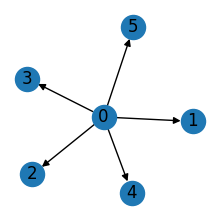

In [22]:
G = dgl.to_networkx(g)
plt.figure(figsize=[2,2])
nx.draw(G, with_labels=True)

In [34]:
#assign node's feature
#weight of edge
g.edata['a'] = torch.Tensor([[1.2, 1.3],
                               [2.1, 2.2],
                                [3.1, 3.2],
                                [4.1, 4.2],
                                [5.1, 5.2]]
                               )

In [48]:
g.edata['a']

tensor([[1.2000, 1.3000],
        [2.1000, 2.2000],
        [3.1000, 3.2000],
        [4.1000, 4.2000],
        [5.1000, 5.2000]])

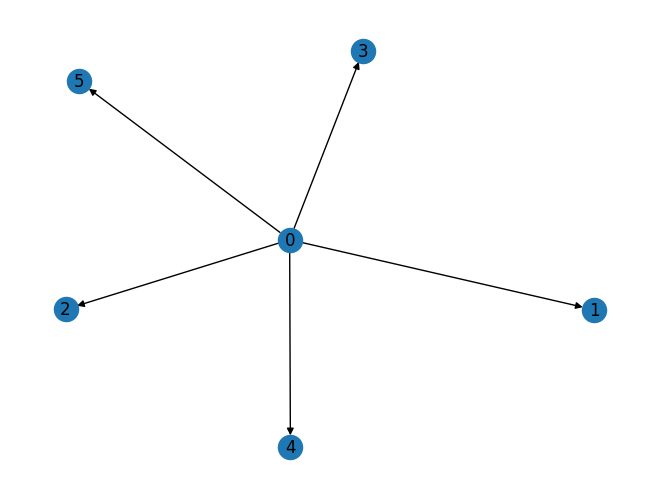

In [35]:
G = dgl.to_networkx(g)
nx.draw(G, with_labels=True)

In [50]:
#get subgraph
#subgraph component is node 0,1,2
subgraph1 = g.subgraph([0,1,2])

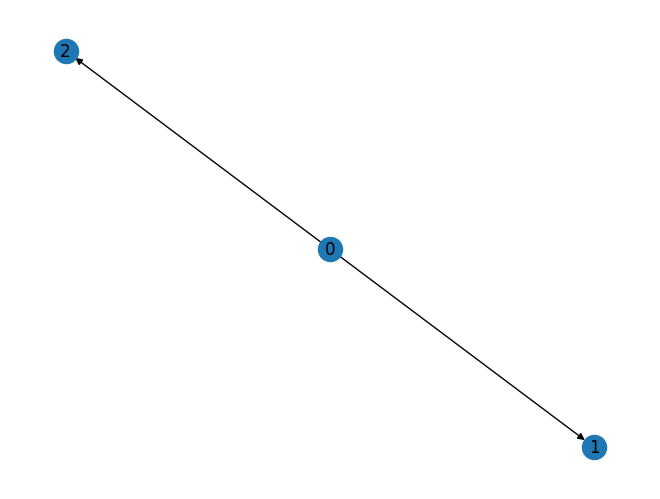

In [49]:
Sub1 = dgl.to_networkx(subgraph1)
nx.draw(Sub1, with_labels=True)

In [51]:
Sub1